### Produce statistical figures

##### tile-level: attention distribution using violin plot

Plots saved to: /data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results/tile_level_attention_distribution.png

AUROC Results:
CLAM: 0.6092
Histolab: 0.6989
Trident: 0.6739
MUFASA: 0.9893


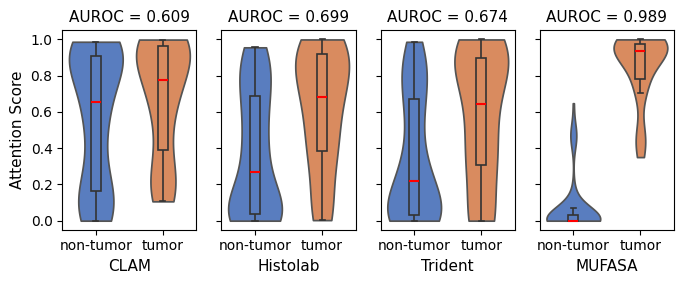

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

def analyze_tile_level_attention_scores(input_path, output_dir):
    """
    Generates tile-level attention distribution plots with:
    1. Fixes for negative values (cut=0) and FutureWarnings.
    2. Reduced font sizes for ticks and labels.
    3. Customized colors for box plot lines and whiskers.
    4. X-axis label as Model Name, Title as only AUROC.
    """
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    # 1. Load Data
    try:
        df = pd.read_csv(input_path)
    except FileNotFoundError:
        print(f"Error: File not found at {input_path}")
        return

    # 2. Map Labels
    if 'label' not in df.columns:
        print("Error: 'label' column not found.")
        return

    if df['label'].dtype == 'object':
        label_mapping = {'tumor': 1, 'non-tumor': 0}
        df['binary_label'] = df['label'].map(label_mapping)
        df = df.dropna(subset=['binary_label'])
    else:
        df['binary_label'] = df['label']

    methods = ['CLAM', 'Histolab', 'Trident', 'MUFASA']
    
    # 3. Generate Plots
    # Slightly adjusted figure size to accommodate smaller fonts if needed
    fig, axes = plt.subplots(1, 4, figsize=(7, 3), sharey=True)
    auroc_results = {}

    # Define custom styling
    TICK_FONT_SIZE = 10
    LABEL_FONT_SIZE = 11  # Increased slightly for Model Name visibility
    TITLE_FONT_SIZE = 11  # Adjusted for single line title
    
    # Define Line/Whisker Color
    LINE_COLOR = '#333333'  # Dark gray/black
    MEDIAN_COLOR = 'red'    # Distinct color for the median line

    for i, method in enumerate(methods):
        col_name = f'{method}_attn_score'
        if col_name not in df.columns:
            continue
            
        ax = axes[i]
        
        # Calculate AUROC
        try:
            auroc = roc_auc_score(df['binary_label'], df[col_name])
            auroc_results[method] = auroc
        except ValueError:
            auroc = float('nan')

        # Violin Plot
        sns.violinplot(
            x='label', 
            y=col_name, 
            hue='label', 
            legend=False, 
            data=df, 
            ax=ax, 
            inner=None, 
            palette="muted", 
            cut=0
        )
        
        # Box Plot Overlay with Custom Colors
        sns.boxplot(
            x='label', 
            y=col_name, 
            data=df, 
            ax=ax, 
            width=0.15, 
            showfliers=False, 
            # Custom properties for lines/whiskers
            boxprops={'facecolor': 'None', 'edgecolor': LINE_COLOR, 'linewidth': 1.2},
            whiskerprops={'color': LINE_COLOR, 'linewidth': 1.2},
            capprops={'color': LINE_COLOR, 'linewidth': 1.2},
            medianprops={'color': MEDIAN_COLOR, 'linewidth': 1.5} # Added medianprops for visibility
        )
        
        # Formatting with Reduced Font Sizes
        # CHANGE 1: Title displays ONLY AUROC
        ax.set_title(f'AUROC = {auroc:.3f}', fontsize=TITLE_FONT_SIZE)
        
        # CHANGE 2: X-axis Label displays Model Name
        ax.set_xlabel(method, fontsize=LABEL_FONT_SIZE, fontweight='normal')
        
        # Adjust Tick Label Size
        ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)

        if i == 0:
            ax.set_ylabel('Attention Score', fontsize=LABEL_FONT_SIZE)
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    
    # Save Plot
    output_plot_path = os.path.join(output_dir, 'tile_level_attention_distribution.png')
    plt.savefig(output_plot_path, dpi=300)
    print(f"Plots saved to: {output_plot_path}")

    # Print Results
    print("\nAUROC Results:")
    for method, score in auroc_results.items():
        print(f"{method}: {score:.4f}")

# --- Configuration ---
input_csv_path = '/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results/tile_level.csv'
output_directory = '/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results'

if __name__ == "__main__":
    analyze_tile_level_attention_scores(input_csv_path, output_directory)

##### wsi/patch-level: Mean Difference in Attention Score (95% CI) and Paired Differences Distribution Wilcoxon 


--- Bootstrap Confidence Intervals (95%) ---
MUFASA vs CLAM: Mean Delta = 0.3061 [0.1859, 0.4385]
MUFASA vs Histolab: Mean Delta = 0.2743 [0.1798, 0.3640]
MUFASA vs Trident: Mean Delta = 0.2562 [0.1534, 0.3629]
Confidence interval plot saved to /data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results/wsi_level_confidence_interval_plot.png

--- Wilcoxon Signed-Rank Test ---
MUFASA vs CLAM: p-value = 9.7656e-04
MUFASA vs Histolab: p-value = 1.9531e-03
MUFASA vs Trident: p-value = 1.9531e-03
Wilcoxon boxplot saved to /data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results/wsi_level_wilcoxon_boxplot.png


/tmp/ipykernel_8206/3077575796.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True, showfliers=False,


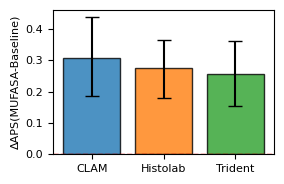

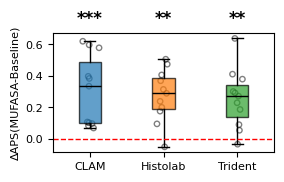

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import os
import argparse

# Set plot style
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.grid': False
})

def bootstrap_ci(data, n_boot=10000, alpha=0.05):
    """Calculates bootstrap confidence interval for the mean."""
    data = np.array(data)
    boot_means = np.random.choice(data, (n_boot, len(data)), replace=True).mean(axis=1)
    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return np.mean(data), lower, upper

def analyze_patch_wsi_level_attention_scores(csv_path, output_dir, level):
    # Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}")
        return

    # Define Baselines and MUFASA column
    baselines = ['CLAM', 'Histolab', 'Trident']
    mufasa_col = 'MUFASA_attn_score'
    
    # Check columns
    for b in baselines:
        if f'{b}_attn_score' not in df.columns:
            print(f"Error: Column {b}_attn_score not found.")
            return

    # Calculate Differences (Delta)
    deltas = {}
    for baseline in baselines:
        deltas[baseline] = df[mufasa_col] - df[f'{baseline}_attn_score']

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # --- Plot 1: Confidence Interval Bar Plot ---
    fig, ax = plt.subplots(figsize=(3, 2))
    colors = ['#1F77B4', '#FF7F0E', '#2CA02C'] # Blue, Orange, Green
    
    means = []
    yerrs = [[], []] # lower, upper errors relative to mean
    
    print("\n--- Bootstrap Confidence Intervals (95%) ---")
    for i, baseline in enumerate(baselines):
        data = deltas[baseline]
        mean, lo, hi = bootstrap_ci(data)
        means.append(mean)
        yerrs[0].append(mean - lo)
        yerrs[1].append(hi - mean)
        print(f"MUFASA vs {baseline}: Mean Delta = {mean:.4f} [{lo:.4f}, {hi:.4f}]")

    # Bar Plot
    bars = ax.bar(baselines, means, yerr=yerrs, capsize=5, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS(MUFASA-Baseline)')
    # ax.set_title('Mean Difference in Attention Score (95% CI)')
    
    plt.tight_layout()
    plot_path1 = os.path.join(output_dir, level+'_level_confidence_interval_plot.png')
    plt.savefig(plot_path1, dpi=400)
    print(f"Confidence interval plot saved to {plot_path1}")
    # plt.show() # Uncomment to show plot

    # --- Plot 2: Wilcoxon Signed-Rank Test Boxplot ---
    fig, ax = plt.subplots(figsize=(3, 2))
    
    # Prepare data for boxplot
    plot_data = [deltas[b] for b in baselines]
    
    # Create Boxplot
    bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True, showfliers=False,
                    medianprops={'color':'black'}, boxprops={'linewidth': 1})

    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add Scatter Points
    for i, data in enumerate(plot_data):
        y = data
        x = np.random.normal(i + 1, 0.04, size=len(y)) # Jitter
        ax.scatter(x, y, alpha=0.5, s=15, facecolors='none', edgecolors='black')

    # Add Statistical Annotations
    y_max = max([d.max() for d in plot_data])
    y_range = y_max - min([d.min() for d in plot_data])
    
    print("\n--- Wilcoxon Signed-Rank Test ---")
    for i, baseline in enumerate(baselines):
        data = deltas[baseline]
        stat, p = wilcoxon(data)
        print(f"MUFASA vs {baseline}: p-value = {p:.4e}")
        
        # Determine significance stars
        if p < 0.001: sig = "***"
        elif p < 0.01: sig = "**"
        elif p < 0.05: sig = "*"
        else: sig = "ns"
        
        # Annotate plot
        ax.text(i + 1, y_max + 0.1 * y_range, sig, ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS(MUFASA-Baseline)')
    # ax.set_title('Paired Differences Distribution')
    
    plt.tight_layout()
    plot_path2 = os.path.join(output_dir, level+'_level_wilcoxon_boxplot.png')
    plt.savefig(plot_path2, dpi=400)
    print(f"Wilcoxon boxplot saved to {plot_path2}")
    # plt.show() # Uncomment to show plot

# --- Configuration ---
input_csv_path = '/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results/wsi_level.csv'
output_directory = '/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/CAMELYON16/Output/CLAM_MB_MIL_Results'

level = "wsi"  # WSI/ROI

if __name__ == "__main__":
    analyze_patch_wsi_level_attention_scores(input_csv_path, output_directory, level)

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(description="Analyze attention scores and generate plots.")
#     parser.add_argument("--input_file", type=str, required=True, help="Path to the input CSV file.")
#     parser.add_argument("--output_folder", type=str, required=True, help="Path to the output folder.")
#     args = parser.parse_args()

#     analyze_attention_scores(args.input_file, args.output_folder)

##### tumor, non-tumor, and artifact retention rates

Plot saved successfully to: /data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/TCGA_LUSC/Output/CLAM_MB_MIL_Results/tumor_artifact_retention_rate.png

Summary Table (Percentage):
Method     CLAM    Histolab     MUFASA  Total    Trident
Label                                                   
Artifact  100.0   93.939394   0.000000  100.0   3.030303
Tumor     100.0  100.000000  96.226415  100.0  33.962264


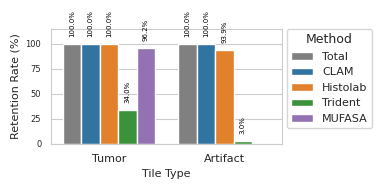

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import argparse
import os

def tumor_artifact_retention_rate(input_file, output_path):
    # 1. Read Data
    try:
        df = pd.read_csv(input_file)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # 2. Identify Label Column
    if 'type' in df.columns:
        lbl_col = 'type'
    elif 'label' in df.columns:
        lbl_col = 'label'
    else:
        print("Error: Column 'type' or 'label' not found.")
        return

    # 3. Define Categories & Methods
    categories = ['tumor', 'artifact']
    methods = ['Total', 'CLAM', 'Histolab', 'Trident', 'MUFASA']
    
    results = []

    for cat in categories:
        # Filter for category (Total Count)
        cat_df = df[df[lbl_col] == cat]
        total_count = len(cat_df)
        
        # Determine total percentage (avoid div/0)
        total_pct = 100.0 if total_count > 0 else 0.0
        
        # Add 'Total' row
        results.append({
            'Label': cat.capitalize(), 
            'Method': 'Total', 
            'Count': total_count, 
            'Percentage': total_pct
        })
        
        if total_count == 0:
            continue

        # Calculate Retention for each method
        for method in methods[1:]: # Skip 'Total'
            if method in df.columns:
                # Logic: Count where Method Column == 1
                count = len(cat_df[cat_df[method] == 1])
                percentage = (count / total_count) * 100
                
                results.append({
                    'Label': cat.capitalize(), 
                    'Method': method, 
                    'Count': count, 
                    'Percentage': percentage
                })

    # 4. Create DataFrame for Plotting
    plot_df = pd.DataFrame(results)
    
    if plot_df.empty:
        print("No data found for the specified categories.")
        return

    # 5. Plotting
    plt.figure(figsize=(4, 2))
    sns.set_style("whitegrid")
    
    # Custom Color Palette
    method_colors = {
        'Total': '#808080',      # Grey
        'CLAM': '#1f77b4',       # Blue
        'Histolab': '#ff7f0e',   # Orange
        'Trident': '#2ca02c',    # Green
        'MUFASA': '#9467bd'      # Purple
    }
    
    # Create Bar Plot
    ax = sns.barplot(
        data=plot_df, 
        x='Label', 
        y='Percentage', 
        hue='Method', 
        palette=method_colors
    )
    
    # Formatting
    # plt.title('Preprocessing Tile Retention Rate (%)', fontsize=10, fontweight='bold')
    plt.ylabel('Retention Rate (%)', fontsize=8)
    plt.xlabel('Tile Type', fontsize=8)
    plt.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=8, title_fontsize=9)
    
    # RESTRICT Y-TICKS TO 100
    plt.ylim(0, 115) # Buffer for labels
    plt.yticks(range(0, 101, 25), fontsize=6) # Ticks: 0, 20, 40, 60, 80, 100
    plt.xticks(fontsize=8)

    # Add Percentage Labels on Bars (Vertical)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha = 'center', va = 'bottom', 
                        fontsize=5, color='black', fontweight='normal',
                        rotation=90,  # Rotated text
                        xytext=(0, 5), textcoords='offset points')
    
    plt.tight_layout()
    
    # Save Plot
    os.makedirs(output_path, exist_ok=True)
    save_file = os.path.join(output_path, 'tumor_artifact_retention_rate.png')
    plt.savefig(save_file, dpi=500, bbox_inches='tight')
    print(f"Plot saved successfully to: {save_file}")
    
    # Print Summary Table
    print("\nSummary Table (Percentage):")
    print(plot_df.pivot(index='Label', columns='Method', values='Percentage').fillna(0)) 
 
input_path = "/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/TCGA_LUSC/Output/CLAM_MB_MIL_Results/tile_level.csv"
output_path = "/data_64T_3/Raja/MUFASA/ATTENTION_ANALYSIS/TCGA_LUSC/Output/CLAM_MB_MIL_Results"

tumor_artifact_retention_rate(input_path, output_path)